In [3]:
!pip -q install awscli

import pandas as pd
import matplotlib.pyplot as plt
import os

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.9/14.9 MB 78.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 570.5/570.5 kB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 5.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sphinx 8.2.3 requires docutils<0.22,>=0.20, but you have docutils 0.19 which is incompatible.


In [4]:
!mkdir -p /content/ds006072

In [5]:
!aws s3 cp --no-sign-request s3://openneuro.org/ds006072/session_data.csv /content/ds006072/

download: s3://openneuro.org/ds006072/session_data.csv to ds006072/session_data.csv


In [6]:
session_df = pd.read_csv("/content/ds006072/session_data.csv")
session_df.head()


,PatientName,SessionID,SessionNumber
0,P1,P1_Baseline1,sub-P1_ses-1
1,P1,P1_Baseline2,sub-P1_ses-2
2,P1,P1_Baseline3,sub-P1_ses-3
3,P1,P1_Baseline4,sub-P1_ses-4
4,P1,P1_Baseline5,sub-P1_ses-5


In [7]:
print("Rows:", len(session_df))
print("Unique participants:", session_df["PatientName"].nunique())
print("Unique Session IDs:", session_df["SessionID"].nunique())

Rows: 129
Unique participants: 11
Unique Session IDs: 129


In [8]:
participant_summary = (
    session_df.groupby("PatientName")
    .agg(
        total_records=("SessionID", "count"),
        unique_sessions=("SessionID", "nunique"),
        min_session_number=("SessionNumber", "min"),
        max_session_number=("SessionNumber", "max")
    )
    .reset_index()
)

participant_summary

,PatientName,total_records,unique_sessions,min_session_number,max_session_number
0,P1,19,19,sub-P1_ses-1,sub-P1_ses-9
1,P1R,5,5,sub-P1R_ses-1,sub-P1R_ses-5
2,P2,21,21,sub-P2_ses-1,sub-P2_ses-9
3,P3,18,18,sub-P3_ses-1,sub-P3_ses-9
4,P3R,3,3,sub-P3R_ses-1,sub-P3R_ses-3
5,P4,15,15,sub-P4_ses-1,sub-P4_ses-9
6,P4R,4,4,sub-P4R_ses-1,sub-P4R_ses-4
7,P5,14,14,sub-P5_ses-1,sub-P5_ses-9
8,P5R,4,4,sub-P5R_ses-1,sub-P5R_ses-4
9,P6,12,12,sub-P6_ses-1,sub-P6_ses-9


In [9]:
participant_summary["is_repeated_id"] = (
    participant_summary["PatientName"].str.endswith("R")
)

participant_summary

,PatientName,total_records,unique_sessions,min_session_number,max_session_number,is_repeated_id
0,P1,19,19,sub-P1_ses-1,sub-P1_ses-9,False
1,P1R,5,5,sub-P1R_ses-1,sub-P1R_ses-5,True
2,P2,21,21,sub-P2_ses-1,sub-P2_ses-9,False
3,P3,18,18,sub-P3_ses-1,sub-P3_ses-9,False
4,P3R,3,3,sub-P3R_ses-1,sub-P3R_ses-3,True
5,P4,15,15,sub-P4_ses-1,sub-P4_ses-9,False
6,P4R,4,4,sub-P4R_ses-1,sub-P4R_ses-4,True
7,P5,14,14,sub-P5_ses-1,sub-P5_ses-9,False
8,P5R,4,4,sub-P5R_ses-1,sub-P5R_ses-4,True
9,P6,12,12,sub-P6_ses-1,sub-P6_ses-9,False


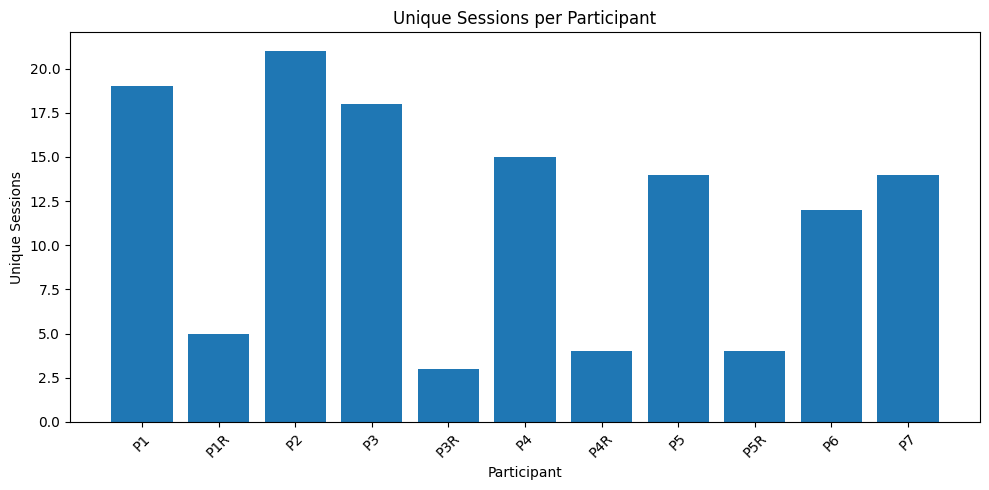

In [10]:
plt.figure(figsize=(10,5))
plt.bar(
    participant_summary["PatientName"],
    participant_summary["unique_sessions"]
)
plt.xticks(rotation=45)
plt.title("Unique Sessions per Participant")
plt.xlabel("Participant")
plt.ylabel("Unique Sessions")
plt.tight_layout()
plt.show()

In [11]:
participant_summary.to_csv(
    "/content/ds006072/participant_inventory.csv",
    index=False
)

print("Saved: participant_inventory.csv")

Saved: participant_inventory.csv


In [12]:
print("Notebook 2 complete.")
print("Participants summarized:", len(participant_summary))
print("Repeated IDs:",
      participant_summary["is_repeated_id"].sum())

Notebook 2 complete.
Participants summarized: 11
Repeated IDs: 4
